In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sympy import symbols, simplify, diff, integrate, solve, lambdify, sqrt, exp, oo
from sympy.plotting import plot, plot3d

In [3]:
import warnings
warnings.filterwarnings("ignore")

## Examples

Suppose a **random variable** follows a density $cx$ for $0\leq x\leq 1$. What is $c$?

In [16]:
x, c = symbols('x c', real=True, positive=True)
pdf = c*x
c0 = solve(integrate(pdf, (x, 0, 1))-1, c)[0]
print(c0)

2


Suppose that a density is of the form $cx^k$ for some constant $k>1$ and $0 < x < 1$. 
What is the value of $c$?

In [15]:
x, c, k = symbols('x c k', real=True, positive=True)
pdf = c*x**k
c0 = solve(integrate(pdf, (x, 0, 1))-1, c)[0]
print(c0)

k + 1


Suppose that a density is of the form $3x^2$ for $x$ between 0 and 1. 
What is the distribution function associated with this density?

In [8]:
x, y = symbols('x y', real=True, positive=True)
pdf = 3*x**2
cdf = simplify(integrate(pdf, (x, 0, y)))
print(cdf)

y**3


Suppose that a density is of the form $(k+1)x^k$ for some constant $k>1$ and $0\leq x\leq 1$. 
What is $\mathbb{E}X^n$ where $n$ is an integer and $X$ is a random variable from this density?

In [9]:
x, k, n = symbols('x k n', real=True, positive=True)
pdf = (k+1)*x**k
# Compute the mean integral of the expression fx with respect to x
meann = simplify(integrate(pdf*x**n, (x, 0, 1)))
print(meann)

(k + 1)/(k + n + 1)


Suppose that a density is of the form $(k+1)x^k$ for some constant $k>1$ and $0 \leq x \leq 1$. What is the mean associated with this density?

In [19]:
x, k = symbols('x k', real=True, positive=True)
pdf = (k+1)*x**k
# Compute the mean integral of the expression fx with respect to x
meann = simplify(integrate(pdf*x, (x, 0, 1)))
print(meann)

(k + 1)/(k + 2)


A Pareto density is $\frac{1}{x^2}$ for $1 < x < \infty$. 
What is the distribution function associated with this density for $1 < x < \infty$?

In [12]:
x, y = symbols('x y', real=True, positive=True)
pdf = 1/x**2
cdf = simplify(integrate(pdf, (x, 1, y)))
print(cdf)

(y - 1)/y


Quality control experts estimate that the time (in years) until a specific electronic part from an assembly line fails follows (a specific instance of) the Pareto density, $f(x)= \frac{3}{x^4}$ for $1<x<\infty$. 
Which option is closest to the mean failure time?

In [20]:
x = symbols('x', real=True, positive=True)
pdf = 3/x**4
# Compute the mean integral of the expression fx with respect to x
meann = simplify(integrate(pdf*x, (x, 1, oo)))
print(meann)

3/2


What is the quantile $p$ from the density $e^{−x}(1+e^{−x})^{−2}$?

In [14]:
x, y = symbols('x y', real=True)
pdf = exp(-x)/(1+exp(-x))**2
p0 = symbols('p0')
# Compute the indefinite integral of the expression f with respect to x
cdf = integrate(pdf, (x, -oo, y))
ppf = solve(cdf-p0, y)[0]
print(ppf)

log(-p0/(p0 - 1))


Consider the density given by $2x\exp(−x^2)$ for $x>0$.
What is the median?

In [18]:
x, y = symbols('x y', real=True)
pdf = 2*x*exp(-x**2)
cdf = integrate(pdf, (x, 0, y))
ppf = solve(cdf-0.5, y)[0]
print(ppf)

-0.832554611157698


# Uniform Distribution

In [5]:
from scipy.stats import uniform

## Introduction

A **uniform distribution** is a probability distribution where all possible outcomes within a specific, finite domain are equally likely. 

## Examples

Suppose a random variable, $X$, follows a **uniform distribution**. 
That is, having a density that is a constant 1 between 0 and 1. 
What is the probability that $X$ is between .1 and .7 expressed as an integer percentage (i.e. no decimal places)?

In [4]:
x = symbols('x', real=True, positive=True)
# create an algebraic expression
pdf = 1
probability = integrate(pdf, (x, .1, .7))
print(100*probability)

60.0000000000000


## Distribution

In [5]:
#define x and y as symbolic variables
x, y, a, b = symbols('x y a b')

In [6]:
aa = 0
bb = 2

### Probability Density Function (`.pdf`)

The probability density function (**pdf**) of the **uniform distribution** is
$$
f(x, \lambda) = 
\begin{cases}
\frac{1}{b-a} & x \in [a, b], \\
0                      & x\notin [a, b].
\end{cases}
$$

In [7]:
# create an algebraic expression
pdf = 1/(b-a)

In [10]:
uniform.pdf(3/2, loc=aa, scale=bb-aa)

np.float64(0.5)

### Cumulative Distribution Function (`.cdf`)

In [11]:
# Compute the indefinite integral of the expression f with respect to x
cdf = integrate(pdf, (x, a, y))
print(cdf)

-a/(-a + b) + y/(-a + b)


Checking

In [27]:
diff(cdf, y)-pdf

0

In [28]:
uniform.cdf(1/2, loc=aa, scale=bb-aa)

np.float64(0.25)

### Quantiles (`.ppf`)

In [26]:
p0 = symbols('p0')
ppf = solve(cdf-p0, y)[0]
print(ppf)

-a*p0 + a + b*p0


In [13]:
a+0.1*(b-a)-ppf

0

In [14]:
cdf_value = 0.7
ppf = uniform.ppf(cdf_value, loc=aa, scale=bb-aa)
print(f"P(X<={ppf} | λ={10}) = {cdf_value}")

P(X<=1.4 | λ=10) = 0.7


### Mean or expected value (`.mean`)

In [ ]:
# Compute the mean integral of the expression fx with respect to x
mean = simplify(integrate(pdf*x, (x, a, b)))
print(mean)

In [16]:
uniform.mean(loc=aa, scale=bb-aa)

np.float64(1.0)

### Variances (`.var`) and Standard Deviation (`.std`)

In [18]:
var = simplify(integrate(pdf*(x-mean)**2, (x, a, b)))
print(var)

a**2/12 - a*b/6 + b**2/12


In [24]:
uniform.var(loc=aa, scale=bb-aa)

np.float64(0.3333333333333333)

In [23]:
std = simplify(sqrt(var))
print(std)

sqrt(3*a**2 - 6*a*b + 3*b**2)/6


In [25]:
uniform.std(loc=aa, scale=bb-aa)

np.float64(0.5773502691896257)

## Visualization

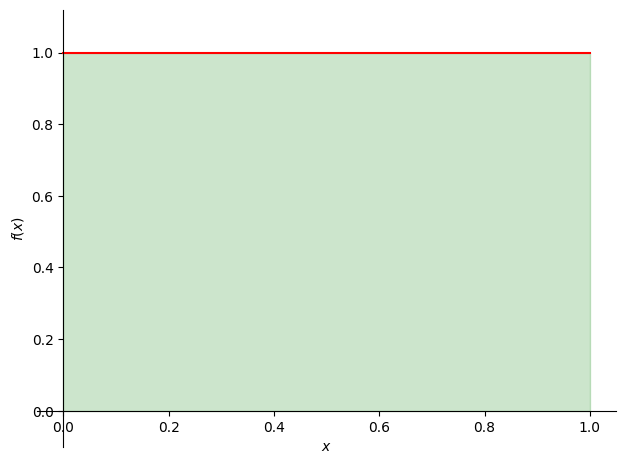

In [14]:
x_array = np.linspace(0, 1, 100)
f_array = lambdify(x, 1)(x_array)
p1 = plot(1+0*x, (x, 0, 1), ylim=(-0.1, 1.12),
          fill={'x': x_array, 'y1': f_array, 'color': 'green', 'alpha': 0.2},
          line_color='red', show=False)
p1.show()

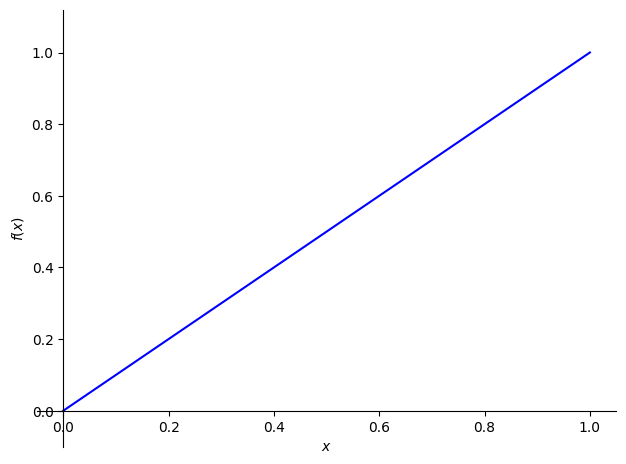

In [17]:
p2 = plot(x, (x, 0, 1), ylim=(-0.1, 1.12), line_color='blue', show=False)
# p2.append(p1[0])
p2.show()

## References

- [SymPy: A Complete Guide to Symbolic Mathematics in Python](https://www.datacamp.com/tutorial/sympy)